# 04 — Feedforward Neural Network (PyTorch)

This notebook trains and evaluates the FNN independently from the classical ML models in `03_modeling.ipynb`.

Architecture: `Input(n) → Linear(64) → ReLU → Dropout(0.3) → Linear(32) → ReLU → Dropout(0.3) → Linear(1) → Sigmoid`

Training uses early stopping (patience=10) on an internal 10% validation split.  
The `FNNWrapper` makes the model compatible with `evaluate_model()` and the plot functions.

Results are saved to `outputs/results/metrics.csv`.  
Plots are saved to `outputs/figures/models/`.

## 0 · Imports

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt

'''Self modules'''
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.models import split_data, get_X_y
from src.fnn import train_fnn, FNNWrapper
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from config import FEATURE_SETS, FEATURE_CONFIG, FIGURES_MODELS, PLOT_DPI

## 1 · Load & Split

Split is done on the **raw** DataFrame before preprocessing.  
This prevents any data leakage from imputation or encoding statistics.

In [2]:
df_raw = load_data()

df_train_raw, df_test_raw = split_data(df_raw, test_seasons=[2022, 2023])

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet
[split_data] Train seasons : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
[split_data] Test  seasons : [np.int32(2022), np.int32(2023)]
[split_data] Train rows    : 286,892
[split_data] Test  rows    : 99,099


## 2 · Preprocess — `final` Feature Set

Train and test sets are preprocessed **independently**.  
The full feature-set loop comes in Section 4.

In [3]:
ACTIVE_FEATURE_SET = "final"

df_train = preprocess(df_train_raw, feature_set=FEATURE_SETS[ACTIVE_FEATURE_SET], feature_config=FEATURE_CONFIG)
df_test  = preprocess(df_test_raw,  feature_set=FEATURE_SETS[ACTIVE_FEATURE_SET], feature_config=FEATURE_CONFIG)

# Sanity check
print(f"Train NaNs : {df_train.isna().sum().sum()}")
print(f"Test  NaNs : {df_test.isna().sum().sum()}")
print(f"Train shape: {df_train.shape}")
print(f"Test  shape: {df_test.shape}")
print(f"Target distribution (train):\n{df_train['target'].value_counts(normalize=True).round(3)}")

X_train, y_train = get_X_y(df_train)
X_test,  y_test  = get_X_y(df_test)


                              PREPROCESSING REPORT                              

INPUT:
   Shape: (286892, 372)
   Missing: 38714249 NaNs (36.28%)

OUTPUT:
   Shape: (203362, 8)
   Features (X): 7 columns
   Target (y): 203362 samples
   Missing: 0 NaNs

SELECTED FEATURES IMPUTATION DETAILS:
   Feature Name                   | NaNs Before  | NaNs After  | Filled/Removed
   ----------------------------------------------------------------------
   shotgun                        | 0            | 0           | 0        | -                       
   down                           | 743          | 0           | 743      | dropped (<1% NaNs)      
   score_differential             | 0            | 0           | 0        | -                       
   ydstogo                        | 0            | 0           | 0        | -                       
   posteam_timeouts_remaining     | 0            | 0           | 0        | -                       
   quarter_seconds_remaining      | 0         

## 3 · Train FNN — `final` Feature Set

In [4]:
fnn_model, fnn_history, fnn_scaler = train_fnn(
    X_train=X_train,
    y_train=y_train,
    val_split=0.1,
    epochs=100,
    batch_size=512,
    lr=3e-4,
    patience=10,
)

fnn_wrapper = FNNWrapper(fnn_model, scaler=fnn_scaler)

  Epoch  10 | train_loss: 0.5559 | val_loss: 0.5461 | no_improve: 0/10
  Epoch  20 | train_loss: 0.5535 | val_loss: 0.5447 | no_improve: 1/10
  Epoch  30 | train_loss: 0.5521 | val_loss: 0.5440 | no_improve: 1/10
  Epoch  40 | train_loss: 0.5506 | val_loss: 0.5443 | no_improve: 8/10
  Epoch  50 | train_loss: 0.5502 | val_loss: 0.5434 | no_improve: 5/10
  Epoch  55 | train_loss: 0.5499 | val_loss: 0.5438 | no_improve: 10/10

[train_fnn] Early stopping at epoch 55.
[train_fnn] Training complete. Best val_loss: 0.5430


### 3.1 Training Curve

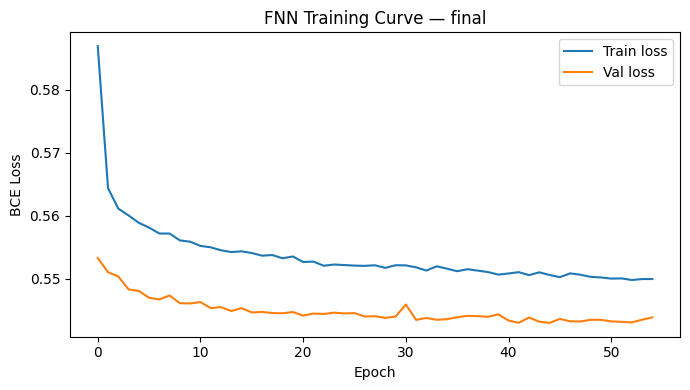

Saved → C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\fnn_training_curve_final.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fnn_history["train_loss"], label="Train loss")
ax.plot(fnn_history["val_loss"],   label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title(f"FNN Training Curve — {ACTIVE_FEATURE_SET}")
ax.legend()
fig.tight_layout()

save_path = FIGURES_MODELS / f"fnn_training_curve_{ACTIVE_FEATURE_SET}.png"
FIGURES_MODELS.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=PLOT_DPI)
plt.show()
print(f"Saved → {save_path}")

### 3.2 Evaluate FNN

In [6]:
metrics_fnn = evaluate_model(
    model=fnn_wrapper,
    X_test=X_test,
    y_test=y_test,
    model_name="FNN",
    feature_set=ACTIVE_FEATURE_SET,
)

plot_confusion_matrix(fnn_wrapper, X_test, y_test, "FNN", ACTIVE_FEATURE_SET)

[evaluate_model] Metrics saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\results\metrics.csv

[evaluate_model] FNN | feature_set=final
  Accuracy  : 0.7135
  F1        : 0.7076
  ROC-AUC   : 0.7759
  Precision : 0.7117
  Recall    : 0.7135

[plot_confusion_matrix] Saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\cm_FNN_final.png


### 3.3 ROC Curve — FNN standalone

In [7]:
plot_roc_curve(
    models={"FNN": fnn_wrapper},
    X_test=X_test,
    y_test=y_test,
    feature_set=ACTIVE_FEATURE_SET,
)

[plot_roc_curve] Saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\models\roc_final.png


## 4 · FNN Feature Set Loop

Train the FNN on all feature sets and collect metrics.

**Note:** This will take a few minutes on CPU — consider running on Google Colab for faster results.

In [12]:
#find largest feature_set and preprocess it
LARGEST_FS = max(FEATURE_SETS, key=lambda k: len(FEATURE_SETS[k]))
_df_train_full = preprocess(df_train_raw, feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)
_df_test_full  = preprocess(df_test_raw,  feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)


                              PREPROCESSING REPORT                              

INPUT:
   Shape: (286892, 372)
   Missing: 38714249 NaNs (36.28%)

OUTPUT:
   Shape: (203362, 14)
   Features (X): 13 columns
   Target (y): 203362 samples
   Missing: 0 NaNs

SELECTED FEATURES IMPUTATION DETAILS:
   Feature Name                   | NaNs Before  | NaNs After  | Filled/Removed
   ----------------------------------------------------------------------
   goal_to_go                     | 0            | 0           | 0        | -                       
   game_seconds_remaining         | 0            | 0           | 0        | -                       
   defteam_timeouts_remaining     | 0            | 0           | 0        | -                       
   yardline_100                   | 0            | 0           | 0        | -                       
   total_line                     | 0            | 0           | 0        | -                       
   wp                             | 0       

In [ ]:
for fs_name, fs_cols in FEATURE_SETS.items():

    print(f"\n{'='*55}")
    print(f" FNN | Feature set: {fs_name}  ({len(fs_cols)} features)")

    is_subset = all(c in _df_train_full.columns for c in fs_cols)
    if is_subset:
        _df_train = _df_train_full[fs_cols + ["target"]]
        _df_test  = _df_test_full[fs_cols  + ["target"]]
    else:
        _df_train = preprocess(df_train_raw, feature_set=fs_cols, feature_config=FEATURE_CONFIG)
        _df_test  = preprocess(df_test_raw,  feature_set=fs_cols, feature_config=FEATURE_CONFIG)

    _X_train, _y_train = get_X_y(_df_train)
    _X_test,  _y_test  = get_X_y(_df_test)

    _fnn_model, _fnn_history, _fnn_scaler = train_fnn(_X_train, _y_train)
    _fnn_wrapper = FNNWrapper(_fnn_model, scaler=_fnn_scaler)

    evaluate_model(_fnn_wrapper, _X_test, _y_test, "FNN", fs_name)

print("\nDone. FNN results saved to metrics.csv")


 FNN | Feature set: final  (7 features)

                              PREPROCESSING REPORT                              

INPUT:
   Shape: (286892, 372)
   Missing: 38714249 NaNs (36.28%)

OUTPUT:
   Shape: (203362, 8)
   Features (X): 7 columns
   Target (y): 203362 samples
   Missing: 0 NaNs

SELECTED FEATURES IMPUTATION DETAILS:
   Feature Name                   | NaNs Before  | NaNs After  | Filled/Removed
   ----------------------------------------------------------------------
   shotgun                        | 0            | 0           | 0        | -                       
   down                           | 743          | 0           | 743      | dropped (<1% NaNs)      
   score_differential             | 0            | 0           | 0        | -                       
   ydstogo                        | 0            | 0           | 0        | -                       
   posteam_timeouts_remaining     | 0            | 0           | 0        | -                       
   qu